# Aufgabe 3 - Datenprojekt zur Vorhersage von Immobilienpreisen

**Assignment**: Programmiersprachen R und Python<br>
**Modul**: Progammtechniken in Data Sience - WEB78<br>
**Betreuer**: Dr. Martin Prause<br>

**Autorin**: Marijke Haupt<br>
**Matrikel-Nr.**: 3013968<br>
**Studiengang**: Data Science  - Master of Science (M.Sc.)<br>
**Abgabedatum**: 12.03.2026


**Datei:** web78_aufgabe_3.ipynb<br>
**Programmiersprache:** Python 3.13.19<br>
**Entwicklungsumgebung**: Anaconda - Jupyter Notebooks<br>

**Datengrundlage**:<br>
- housedata.csv (generiert aus "Ames Housing Data" - Kaggle)

**Ziel**:<br> 
- Vorhersage der Zielvariable "AboveMedianPrice" mittels Klassifikationsalgorithmen

**Teilaufgaben**:
- 3a) Datenanalyse und -aufbereitung
- 3b) Modellbildung und Evaluation

## Einleitung

Im Rahmen des Moduls *Programmtechniken in Data Science (WEB78)* besteht die Prüfungsaufgabe darin, ein vollständiges Datenprojekt zur Vorhersage von Immobilienpreisen durchzuführen. Ziel ist es, mithilfe geeigneter Klassifikationsverfahren zu bestimmen, ob der Preis eines Hauses unter dem Medianpreis oder darüber liegt. Als Datengrundlage dient eine vereinfachte Version des Ames-Housing-Datensatzes, der zahlreiche strukturelle und ausstattungsbezogene Merkmale von Wohnimmobilien enthält.<br>

Die Bearbeitung gliedert sich in zwei zentrale Teilaufgaben:<br>

**(1) Datenanalyse und -aufbereitung (Aufgabe 3a)**<br>
Zunächst wird der Datensatz systematisch untersucht, bereinigt und explorativ analysiert. Dazu gehören die Prüfung der Datentypen, die Identifikation fehlender Werte und doppelter Zeilen, sowie eine umfassende Ausreißeranalyse. Anschließend erfolgt eine univariate, bivariate und multivariate explorative Datenanalyse (EDA), um Verteilungen, Zusammenhänge und Multikollinearität sichtbar zu machen. Auf Basis dieser Analyse wird eine begründete redundanzfreie und prädikativ sinnvolle Merkmalsauswahl für die Modellbildung getroffen.<br>

**(2) Modellbildung und Evaluation (Aufgabe 3b)**<br>
Im zweiten Schritt werden drei Klassifikationsmodelle implementiert, die unterschiedliche mathematische Prinzipien repräsentieren: die logistische Regression (lineares Modell), k-Nearest Neighbors (distanzbasiertes Modell) und der Random Forest (baumbasiertes Ensemlemodell). Die Modelle werden auf einem konsistenten Merkmalsraum trainiert, getestet und anhand von Confusion-Matrizen sowie Accuracy-Scores evaluiert. Ergänzend wird die Feature-Importance des Random Forest analysiert, um die Relevanz der gewählten Merkmale modellbasiert zu validieren.<br>

Die Arbeit folgt damit einem klaren strukturierten, datenwissenschaftlichen Workflow: Datenbereinigung -> EDA -> Merkmalsselektion -> Modellierung -> Evaluation. Durch die Kombination aus statistischer Analyse, visueller Exploration und algorithmischer Modellierung entsteht ein fundiertes Gesamtbild über die prädikativen Eigenschaften der Immobiliendaten und die Leistungsfähigkeit verschiedener Klassifikationsverfahren.<br>

**Meinem eigenen wissenschaftlichen Anspruch entsprechend lege ich großen Wert darauf, meine Vorgehensweise transparent, nachvollziehbar und fundiert zu begründen. Dies führt im Ergebnis zu einem umfangreichen Notebook, dessen Ziel es ist, nicht nur die Ergebnisse zu präsentieren, sondern auch den analytischen Entscheidungsprozess klar und stringent darzustellen.**

## 1. Bibliotheken und Daten laden

### 1.1 Import der Bibliotheken

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, 
                             ConfusionMatrixDisplay, 
                             classification_report,
                             accuracy_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

### 1.2 Laden der Datensätze

In [3]:
house_df = pd.read_csv("housedata.csv")

## 2. Erste Übersicht über die Daten

Bevor mit der detaillierten Datenbereinigung begonnen wird, ist es sinnvoll, sich zunächst einen grundlegenden Überblick über den Datensatz zu verschaffen. Dieser erste Schritt dient dazu, die Struktur, Größe und inhaltliche Zusammensetzung der Daten zu verstehen und potenzielle Besonderheiten frühzeitig zu erkennen. Durch die Betrachtung zentraler Eigenschaften wie Anzahl der Beobachtungen und Variablen, Datentypen sowie erste Stichproben der Daten lassen sich wichtige Rahmenbedingungen für die spätere Analyse ableiten. Es wird ein Dictionary erstellt, um die vorhandenen Variablen zu erläutern. Die folgenden Abschnitte bilden die Grundlage für alle weiteren Schritte im wissenschaftlichen Workflow.

### 2.1 Grundlegende Informationen 

In [4]:
house_df.shape, house_df.keys()

((1460, 11),
 Index(['LotArea', 'OverallQual', 'OverallCond', 'TotalBsmtSF', 'FullBath',
        'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea',
        'AboveMedianPrice'],
       dtype='object'))

Der Datensatz hat 1.460 Zeilen und 11 Spalten.

In [5]:
house_df.head() # Erste Sichtprüfung

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1


**Data-Dictionary:**<br>
Bei dem Datensatz handelt es sich um eine vereinfacht Version des Ames-Housing-Datensatzes, der auf Kaggle zu finden ist: ["Ames Housing Data"](https://github.com/eugeneyan84/Ames-Housing-Data-Analysis/blob/main/DataDocumentation.txt). Eine offizielle Dokumentation dazu gibt es auf GitHub: [DataDocumentation_Ames Housing](https://github.com/eugeneyan84/Ames-Housing-Data-Analysis/blob/main/DataDocumentation.txt).<br>
 Mit den Informationen aus obigen Datenübersichten, lässt sich folgendes Dictionary erstellen.

| Merkmal            | Datenskala      | Beschreibung |
|--------------------|-----------------|--------------|
| AboveMedianPrice   | nominal (binär) |Zielvariable: 1 = Hauspreis über Median, 0 = unter Median |
| LotArea            | metrisch | Grundstücksfläche in Quadratfuß |
| OverallQual        | ordinal | Gesamtqualität des Hauses (1 = sehr schlecht, 10 = sehr gut) |
| OverallCond        | ordinal | Gesamtzustand des Hauses (1 = sehr schlecht, 10 = sehr gut) |
| TotalBsmtSF        | metrisch | Gesamtfläche des Kellers in Quadratfuß |
| FullBath           | diskret | Anzahl der Badezimmer |
| HalfBath           | diskret | Anzahl halber Badezimmer |
| BedroomAbvGr       | diskret | Anzahl der Schlafzimmer oberhalb des Erdgeschosses |
| TotRmsAbvGrd       | diskret | Gesamtanzahl der Räume oberhalb des Erdgeschosses
| Fireplaces         | diskret | Anzahl der Kamine
| GarageArea         | metrisch | Fläche der Garage in Quadratfuß


## 3. Datenbereinigung - Aufgabe 3a) - Teil 1

Die Datenbereinigung bildet einen zentralen Schritt im datenwissenschaftlichen Workflow und stellt sicher, dass die anschließende Analyse auf einer verlässlichen und konsistenten Datengrundlage basiert. Bevor Modelle trainiert werden können, müssen strukturelle Eigenschaften des Datensatzes geprüft und potenzielle Probleme wie fehlende Werte, Duplikate oder Ausreißer identifiziert werden. Eine sorgfältige Bereinigung erhöht nicht nur die Qualität der späteren Modellierung, sondern verhindert auch Verzerrungen, die durch Beobachtungen entstehen können. Im folgenden Abschnitt wird der Datensatz daher systematisch untersucht, bereinigt und für die eplorative Analyse vorbereitet.

### 3.1 Datentypen (strukturelle Prüfung)

In [6]:
house_df.info() # strukturelle Prüfung

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LotArea           1460 non-null   int64
 1   OverallQual       1460 non-null   int64
 2   OverallCond       1460 non-null   int64
 3   TotalBsmtSF       1460 non-null   int64
 4   FullBath          1460 non-null   int64
 5   HalfBath          1460 non-null   int64
 6   BedroomAbvGr      1460 non-null   int64
 7   TotRmsAbvGrd      1460 non-null   int64
 8   Fireplaces        1460 non-null   int64
 9   GarageArea        1460 non-null   int64
 10  AboveMedianPrice  1460 non-null   int64
dtypes: int64(11)
memory usage: 125.6 KB


**Auswertung**
- Alle Variablen liegen numerisch (int64) vor. Daher sind sie ohne weitere Transformation für die geplanten Klassifikationsmodelle verwendbar. 
- Die Funktion info() zeigt bereits, dass keine Spalte fehlende Werte enthält. Zur vollständigen quantitativen Bestätigung wird im Folgenden zusätzlich isna().sum ausgeführt.

### 3.2 Fehlende Werte

In [7]:
house_df.isna().sum()

LotArea             0
OverallQual         0
OverallCond         0
TotalBsmtSF         0
FullBath            0
HalfBath            0
BedroomAbvGr        0
TotRmsAbvGrd        0
Fireplaces          0
GarageArea          0
AboveMedianPrice    0
dtype: int64

**Auswertung** 
- Hiermit ist verifiziert, dass es keine fehlenden Werte gibt.
- Es sind keine NA-Behandlungen notwendig.

### 3.3 Duplikate

In [8]:
house_df.duplicated().sum()   # Duplikat-Prüfung

np.int64(7)

**Auswertung und Beurteilung**<br>

Es gibt sieben Duplikatzeilen im Datensatz. Doppelte Zeilen können die Modellbildung verzerren, da identische Beobachtungen mehrfach gewichtet werden. Dies führt zu einer künstlichen Verstärkung bestimmter Muster und kann die Generalisierbarkeit der Modelle beeinträchtigen. Daher werden die Duplikate nachfolgend entfernt.

In [9]:
house_df = house_df.drop_duplicates()    # Duplikate entfernen
house_df.shape

(1453, 11)

Der Datensatz hat nun 7 Zeilen weniger. 

### 3.4 Ausreißeranalyse

In dieser Ausreißeranalyse werden alle numerischen Variablen mithilfe von Boxplots untersucht, um extreme Werte systematisch zu identifizieren. 

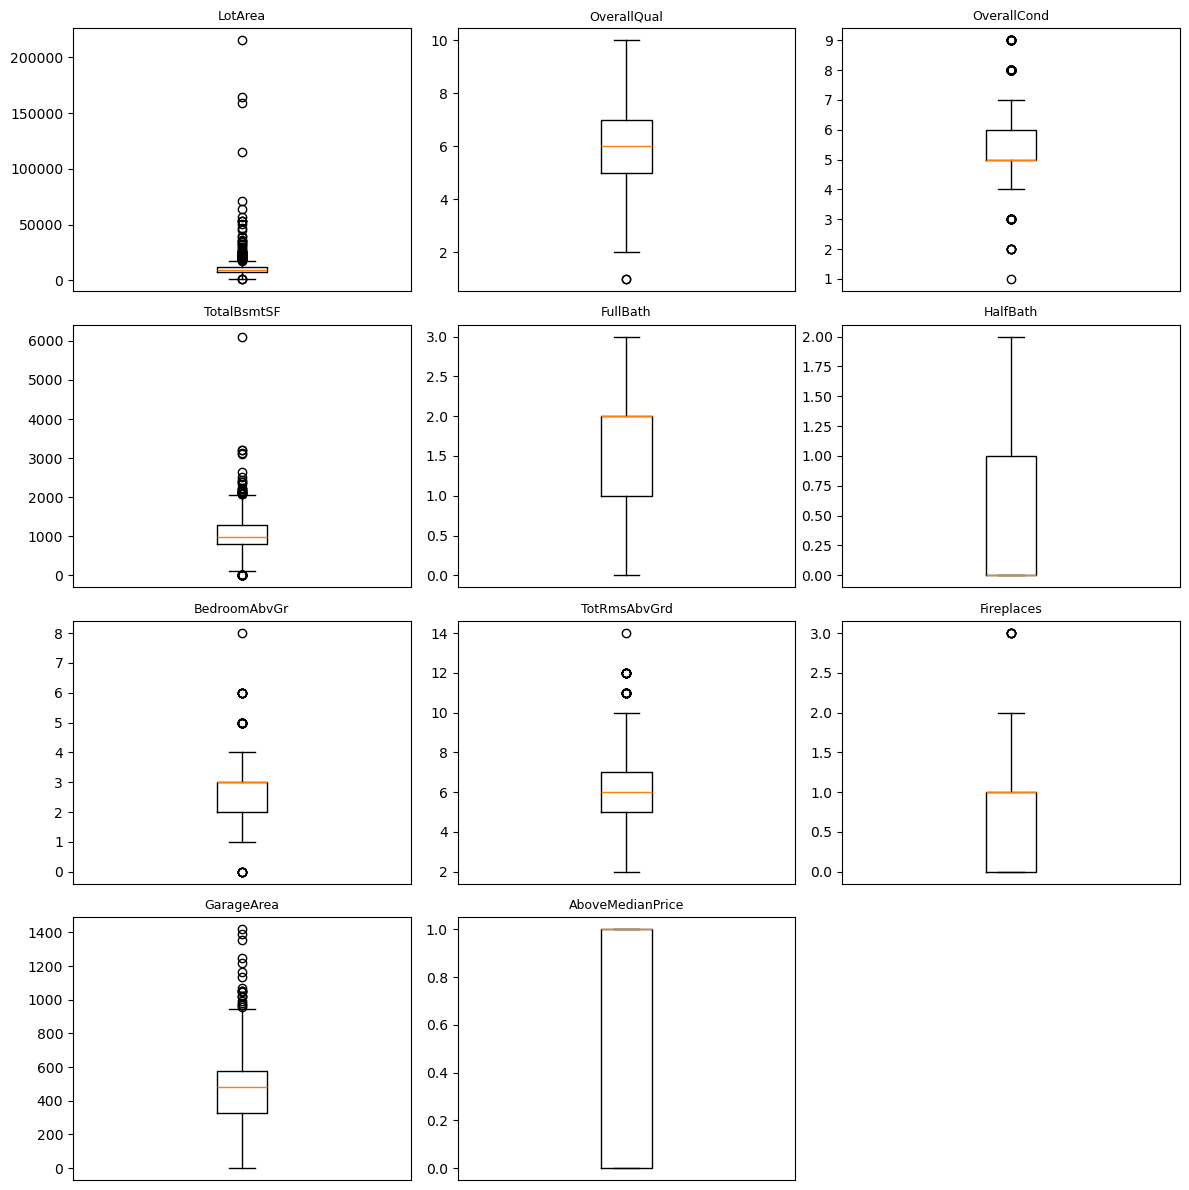

In [10]:
numeric_cols = house_df.select_dtypes(include=np.number).columns

n_cols = 3                     # Anzahl Boxplots pro Zeile für Rasterdarstellung
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)    # Rasterdarstellung
    plt.boxplot(house_df[col].dropna())
    plt.title(col, fontsize=9)
    plt.xticks([])

plt.tight_layout()
plt.show()

**Auswertung**

Folgende Variablen zeigen deutliche Ausreißer:
- LotArea
- TotalBsmtSF
- GarageArea
- TotRmsAbvGrd

Die identifizierten Extremwerte sind inhaltlich plausibel und spiegeln realistische Besonderheiten
des Immobilienmarktes wider (z. B. sehr große Grundstücke oder außergewöhnlich große Garagen).
Es handelt sich daher wahrscheinlich nicht um fehlerhafte Messwerte, sondern um valide Beobachtungen.

Ein Entfernen dieser Werte würde:
- die Varianz künstlich reduzieren,
- die Repräsentativität des Datensatzes beeinträchtigen,
- insbesondere große oder luxuriöse Immobilien eliminieren.

Da distanz- und gradientenbasierte Modelle wie KNN und logistische Regression sensibler auf
Ausreißer reagieren, während baumbasierte Modelle wie der Random Forest robuster sind, wird
dieser Aspekt in der späteren Modellbewertung berücksichtigt. Die Ausreißer werden bewusst
beibehalten, um die reale Struktur des Immobilienmarktes abzubilden.

## 4. Explorative Datenanalyse (EDA) - Aufgabe 3a) - Teil 2

Die explorative Datenanalyse dient dazu, ein tieferes Verständnis über die Struktur, Verteilungen und Zusammenhänge der Variablen zu erhalten. Ziel ist es, relevante Merkmale für die Vorhersagemodell herauszufiltern.

Die EDA umfasst:
- Univariate Analyse: Verteilungen und Kennzahlen einzelner Variablen
- Bivariate Analyse: Zusammenhänge zwischen den einzelnen Variablen zur Zielvariable
- Multivariate Analyse: Korrelationsanalyse mittels Heatmap
- Identifikation relevanter Merkmale für die Modellbildung

Durch die Kombination aus univariaten Analyse, bivariaten Vergleichen zur Zielvariablen und einer multivariaten Korrelationsanalyse entsteht ein umfassendes Bild darüber, welche Variablen prädikativ stark, redundant oder nur begrenzt informativ sind. Die EDA dient damit unmittelbar der fundierten Merkmalsauswahl, die als Grundlage für die Modellbildung in Aufgabe 3b) dient.

### 4.1 Univariate Analyse: Verteilung und statistische Kennzahlen

In der univariaten Analyse werden zunächst alle Variablen einzeln betrachtet, um ihre grundlegenden statistischen Eigenschaften und Verteilungen zu verstehen. Dabei werden zentrale Lage- und Streuungsmaße sowie die Form der Verteilungen untersucht, um erste Hinweise auf Schiefe oder Varianz zu erhalten. Abschließend wird auch die Verteilung der Zielvariable selbst analysiert, um die Ausgangslage für die spätere Modellbildung einzuordnen.

#### 4.1.1 Statistische Kennzahlen

In [11]:
# Numerische Variablen außer der Zielvariablen
num_cols = house_df.columns.drop("AboveMedianPrice")

In [12]:
house_df[num_cols].describe().round(3)    #Ausgabe auf 3 Nachkommastellen runden

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea
count,1453.000,1453.000,1453.000,1453.000,1453.000,1453.000,1453.000,1453.000,1453.000,1453.000
mean,10542.659,6.103,5.579,1059.692,1.565,0.384,2.872,6.526,0.615,473.249
std,9997.116,1.381,1.113,437.727,0.551,0.503,0.812,1.621,0.645,214.275
min,1300.000,1.000,1.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000
25%,7577.000,5.000,5.000,796.000,1.000,0.000,2.000,5.000,0.000,328.000
50%,9500.000,6.000,5.000,992.000,2.000,0.000,3.000,6.000,1.000,480.000
75%,11616.000,7.000,6.000,1300.000,2.000,1.000,3.000,7.000,1.000,576.000
max,215245.000,10.000,9.000,6110.000,3.000,2.000,8.000,14.000,3.000,1418.000


#### 4.1.2 Verteilung der Daten (Histogramme)

<function matplotlib.pyplot.show(close=None, block=None)>

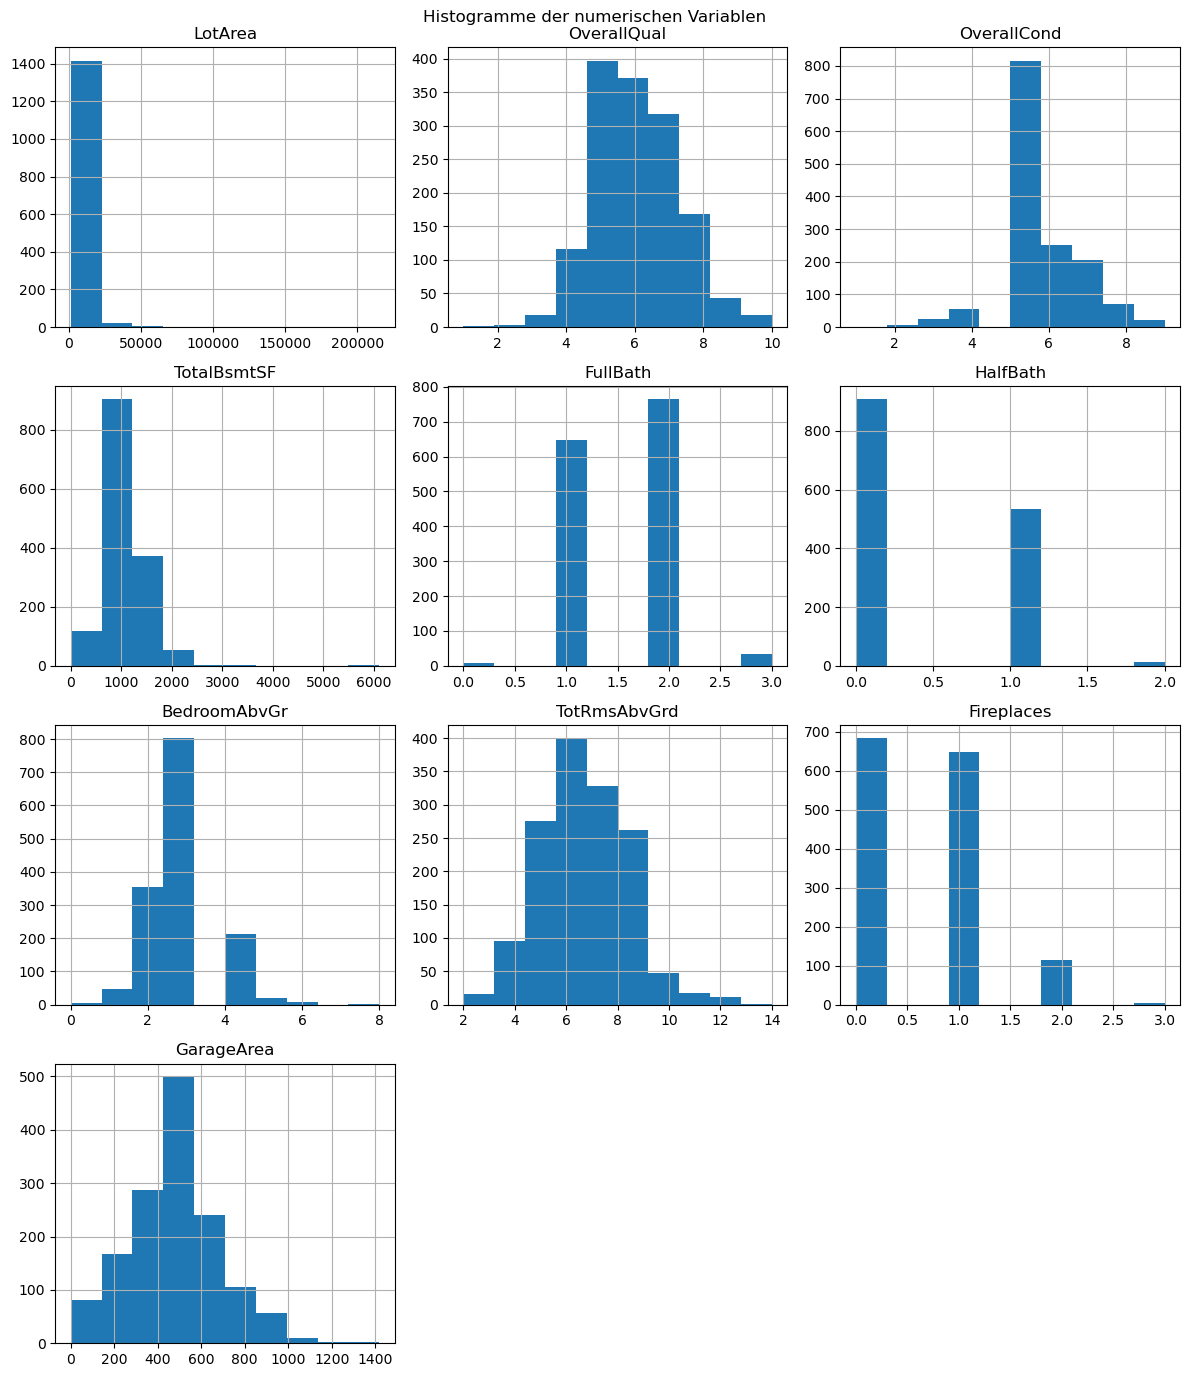

In [13]:
house_df[num_cols].hist(figsize = (12,14))
plt.suptitle("Histogramme der numerischen Variablen")
plt.tight_layout()
plt.show

**Auswertung zu 3.1 und 3.2:**

Die univariate Analyse zeigt deutliche Unterschiede in Verteilung, Streuung und Schiefe der einzelnen Merkmale. Besonders auffällig ist, dass mehrere Variablen stark rechtsschief verteilt sind, was typisch für Immobilienmärkte ist, in denen wenige sehr große oder hochwertige Objekte existieren.

**LotArea (Grundstücksfläche)**  
Die Variable weist eine sehr extreme Rechtsschiefe auf. Der Median liegt bei 9.478 ft², während der Mittelwert mit 10.517 ft² deutlich höher ist. Das 75%-Quantil beträgt 11.602 ft², der Maximalwert jedoch 215.245 ft² – also fast das Zwanzigfache des oberen Quartils. Diese Verteilung ist typisch für reale Grundstücksgrößen: viele kleine Grundstücke und wenige sehr große. 

**TotalBsmtSF (Kellerfläche)**  
Auch diese Variable ist deutlich rechtsschief. Der Median liegt bei 992 ft², das 75%-Quantil bei 1.298 ft², während der Maximalwert 6.110 ft² beträgt. Die Standardabweichung von 439 ft² zeigt eine breite Streuung. Die Extremwerte entsprechen realistischen großen Immobilien und werden daher beibehalten.

**GarageArea (Garagenfläche)**  
Die Verteilung ist ebenfalls rechtsschief, wenn auch weniger extrem. Der Median beträgt 480 ft², das 75%-Quantil 576 ft², der Maximalwert jedoch 1.418 ft². Auch hier handelt es sich um realistische Beobachtungen, die große oder mehrfach ausgebaute Garagen widerspiegeln.

**OverallQual und OverallCond (Qualität und Zustand)**  
Beide Variablen sind ordinal skaliert. OverallQual zeigt eine klare Konzentration im Bereich 5–7 (Median = 6), während sehr niedrige und sehr hohe Werte selten sind. OverallCond ist ähnlich verteilt, weist jedoch eine geringere Streuung auf und liefert gegenüber OverallQual kaum zusätzliche Information (Redundanz).

**Diskrete Ausstattungsmerkmale (FullBath, HalfBath, BedroomAbvGr, TotRmsAbvGrd, Fireplaces)**  
Diese Variablen zeigen typische diskrete Verteilungen mit wenigen Ausprägungen. FullBath und TotRmsAbvGrd weisen eine moderate Streuung auf, während HalfBath und Fireplaces stärker konzentriert sind (z. B. Fireplaces: Median = 1, Max = 3).

**Fazit**<br>
Die hohen Extremwerte in eingien Variablen sind, wie in Kapitel 3.4 bereits erläutert, plausibel und stellen keine Messfehler dar. Eine Entfernung oder Transformation würde die Repräsentativität des Datensatzes beeinträchtigen und insbesondere große, hochpreisige Immobilien aus der Analyse ausschließen. Da die Daten später skaliert werden und baumbasierte Modelle robust gegenüber Ausreißern sind, wird bewusst auf eine Bereinigung verzichtet.<br>
Mit einer einer Log-Transformation könnten die stark rechtsschiefen Variablen gestaucht werden, sodass auch Ausreißer nicht mehr so dominant wirken. Es wird hier bewusst darauf verzichtet. Die Interpretierbarkeit der Merkmale würde sinken, und baumbasierte Modelle wie der Random Forest profitieren nicht von solchen Transformationen.
Da die Daten später skaliert werden und baumbasierte Modelle robust gegenüber Ausreißern und Schiefe sind, wird bewusst auf eine Bereinigung verzichtet.<br>

Insgesamt zeigt die univariate Analyse, dass die Verteilungen der Merkmale realistische Marktstrukturen widerspiegeln. Die Extremwerte werden daher beibehalten, um die Varianz und Repräsentativität des Datensatzes zu erhalten.

#### 4.2.3 Verteilung der Zielvariablen

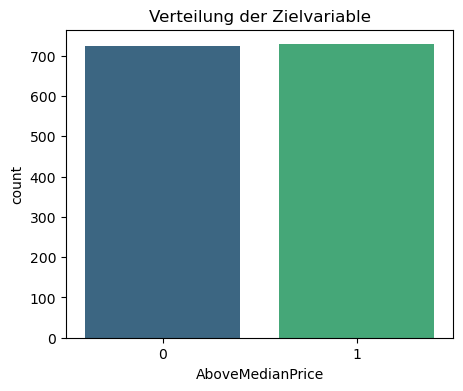

In [14]:
plt.figure(figsize = (5,4))
sns.countplot(
    data = house_df,
    x="AboveMedianPrice",
    hue="AboveMedianPrice",  # notwenig, um palette zu nutzen
    palette="viridis",
    legend=False)
plt.title("Verteilung der Zielvariable")
plt.show()

In [15]:
house_df['AboveMedianPrice'].value_counts()

AboveMedianPrice
1    728
0    725
Name: count, dtype: int64

**Auswertung**<br>

Das Histogramm zeigt eine Gleichverteilung der Beobachtungen bei den beiden Ausprägungen der Zielvariablen: es gibt 728 Immobilien über dem Medianpreis und 725 Immobilien unter dem Medianpreis. Eine ausbalancierte Zielvariable ist sehr vorteilhaft für Klassifikationsaufgaben. Damit gibt es ausreichend Beobachtungen zu beiden Ausprägungen, um die Vorhersagemodelle zu trainieren.

### 4.2 Bivariate Analyse: Zusamenhänge zur Zielvariablen

In der bvivariaten Analyse werden die Beziehungen zwischen den einzelnen Merkmalen zur Zielvariable AboveMedianPrice untersucht. Ziel ist es, sichtbar zu machen, welche Variablen deutliche Unterschiede zwischen den beiden Preisgruppen aufweisen und damit potenziell prädikative Relevanz besitzen. Durch den Vergleich der Verteilungen sowie die Berechnung der Korrelationen lassen sich erste Hinweise darauf gewinnen, welche Merkmale zur späteren Modellbildung besonders geeignet sind.

#### 4.2.1 Boxplots und Korrelationen

Da die Zielvariable binär ist (0 = unter Medianpreis, 1 = über Medianpreis), eignen sich Boxplots besonders gut zur Untersuchung der prädikativen Eigenschaften der einzelnen Variablen. Scatterplots beispielsweise erzeugen bei dieser binären Zielvariablen lediglich kleine schwer interpretierbare Punktwolken und können visuell Cluster suggerieren, die aber statistisch nicht linear sind (ich hatte die Scatterplots zunächst erstellt und erkannte diese Problematik insbesondere bei LotArea). Boxplots zeigen klarer die Lage- und Streuungsunterschiede zwischen den beiden Klassen und sind daher aussagekräftiger.

Zusätzlich werden Korrelationen berechnet und in jedem Plot angezeigt. Die Boxplots werden nach der Stärke der Korrelationen zur Zielvariablen sortiert, sodass die prädikativsten Merkmale zuerst erscheinen. Dies erleichtert die visuelle Bewertung der Merkmalsrelevanz erheblich.

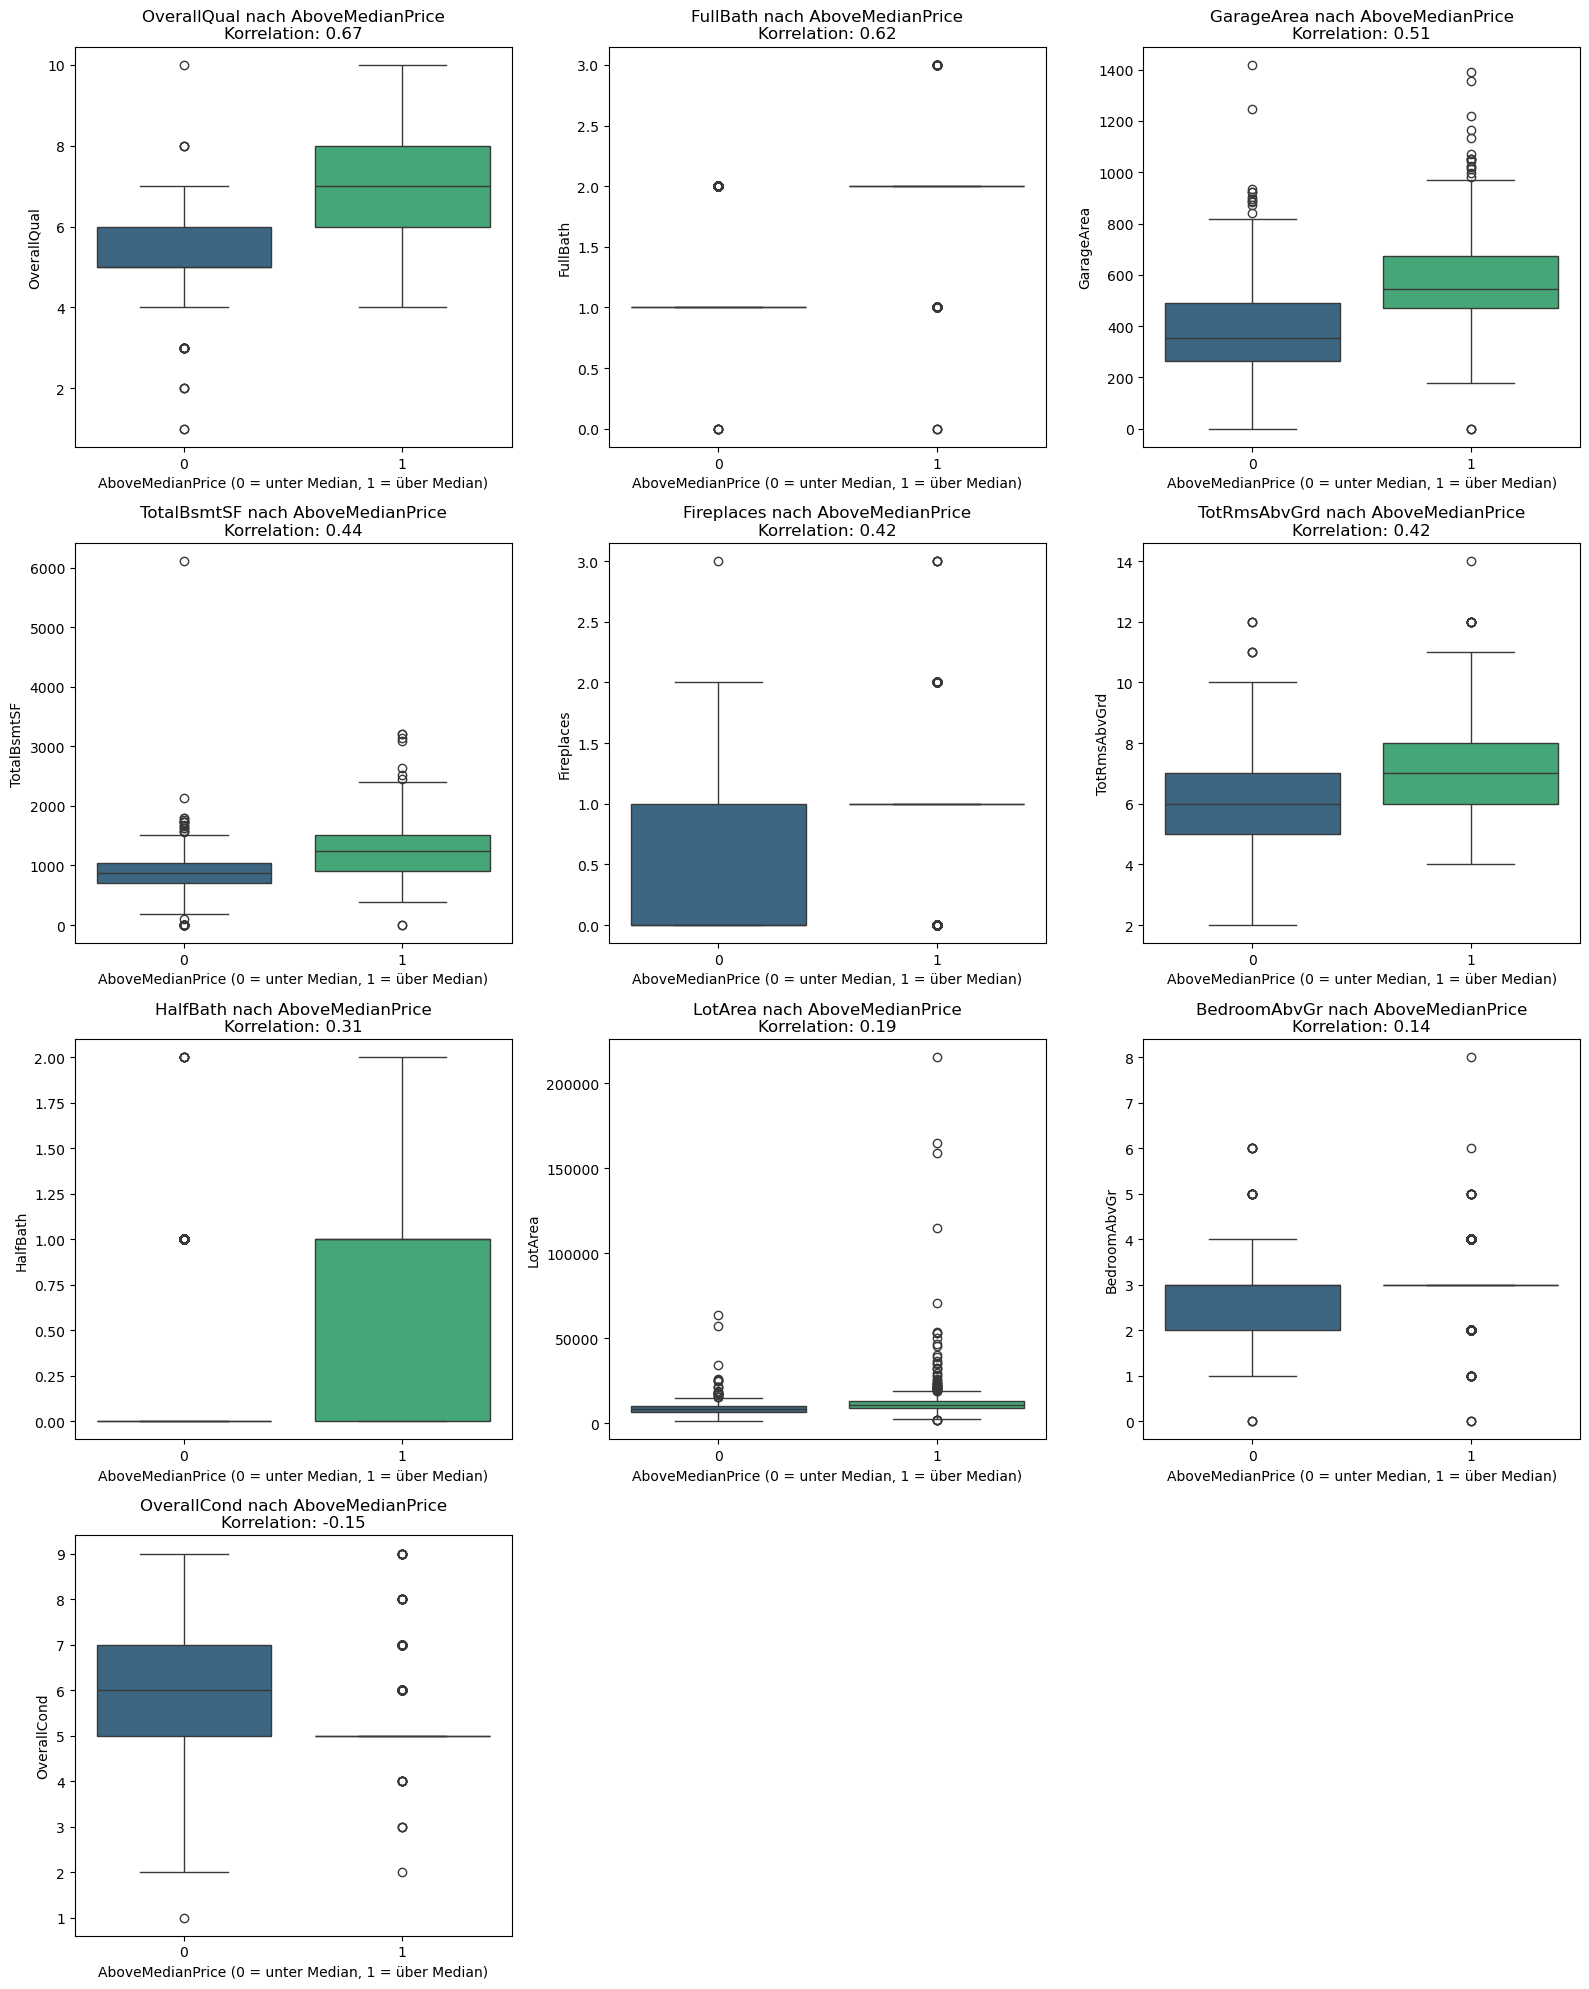

In [16]:
# Numerische Variablen außer der Zielvariable
num_cols = house_df.columns.drop("AboveMedianPrice")
# Korrelationen zur Zielvariable in die Visualisierung integrieren
corr_target = house_df.corr()["AboveMedianPrice"]

# Sortierte Variablenliste anhand Korrelationswerte (absteigend)
sorted_cols = corr_target.drop("AboveMedianPrice").sort_values(ascending=False).index

# Visualisierung
plt.figure(figsize=(16, 20))  # Layout festlegen

for i, col in enumerate(sorted_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(
        data=house_df,
        x="AboveMedianPrice", 
        y=col, 
        hue="AboveMedianPrice",  # notwenig, um palette zu nutzen
        palette="viridis",
    legend=False)   # Legende für die Übersichtlichkeit ausblenden
    plt.title(f"{col} nach AboveMedianPrice\nKorrelation: {corr_target[col]:.2f}")
    plt.xlabel("AboveMedianPrice (0 = unter Median, 1 = über Median)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


**Auswertung der bivariaten Analyse (Boxplots + Korrelationen)**

Die bivariate Analyse zeigt, wie sich die Verteilungen der einzelnen Merkmale zwischen den beiden Preisgruppen unterscheiden (0 = unter Medianpreis, 1 = über Medianpreis). Die Boxplots sind nach absteigender Korrelation sortiert und ermöglichen eine visuelle Einschätzung der prädiktiven Eigenschaften der Merkmale. Die Kombination aus Lageunterschieden, Überlappung und Korrelationswerten erlaubt eine Einordnung in starke, mittlere und schwache Prädiktoren.

**Starke prädiktive Merkmale**

Diese Variablen zeigen deutliche Lageunterschiede zwischen den Preisgruppen, geringe Überlappung der Boxplots und hohe Korrelationswerte. Sie unterscheiden die beiden Klassen visuell klar und konsistent:

- **OverallQual (0.67)**  
Die Qualitätsbewertung trennt die Preisgruppen sehr deutlich. Häuser über dem Medianpreis weisen durchgehend höhere Qualitätsstufen auf. Der Median der Klasse 1 liegt mehrere Stufen über dem Median der Klasse 0.

- **FullBath (0.62)**  
Die Anzahl der Vollbäder ist in der höheren Preisklasse sichtbar größer. Die Boxplots sind klar verschoben, und die Klasse 1 zeigt eine höhere Konzentration bei zwei oder mehr Bädern.

- **GarageArea (0.51)**  
Die Garagenfläche ist in der höheren Preisklasse deutlich größer. Die Lageparameter unterscheiden sich klar, und die Überlappung ist gering.

- **TotalBsmtSF (0.44)**  
Die Kellerfläche ist in der höheren Preisklasse tendenziell größer. Die Boxplots zeigen eine deutliche Verschiebung nach oben.

- **Fireplaces (0.42)**  
Häuser über dem Medianpreis verfügen häufiger über mindestens einen Kamin. Die Klasse 1 zeigt höhere Medianwerte und eine breitere Verteilung.

- **TotRmsAbvGrd (0.42)**  
Die Anzahl der Räume oberhalb des Erdgeschosses ist in der höheren Preisklasse größer. Die Boxplots zeigen eine klare Verschiebung nach oben.

Diese Merkmale weisen sowohl visuell als auch statistisch eine starke Trennschärfe auf und sind daher als **stark prädiktiv** einzustufen.

**Mittlere prädiktive Merkmale**

- **HalfBath (0.31)**  
Die Klasse 1 weist tendenziell mehr Halbbäder auf, jedoch mit stärkerer Überlappung der Boxplots. Der Median ist leicht erhöht. Die Unterschiede sind sichtbar, aber weniger ausgeprägt als bei den starken Prädiktoren.

**Schwache oder nicht-lineare prädiktive Merkmale**

Diese Merkmale zeigen entweder geringe Lageunterschiede, starke Überlappung oder nicht-lineare Zusammenhänge, die durch die Korrelation nur unzureichend abgebildet werden.

- **LotArea (0.19)**  
Trotz einzelner großer Grundstücke in beiden Klassen ist die Überlappung sehr hoch. Der Median unterscheidet sich nur geringfügig. Die Variable zeigt visuell nur geringe Trennschärfe.

- **BedroomAbvGr (0.14)**  
Die Boxplots zeigen sichtbare, aber nicht-lineare Unterschiede:  
Häuser mit **2 Schlafzimmern** liegen häufiger unter dem Medianpreis, während Häuser mit **4 oder mehr Schlafzimmern** häufiger über dem Medianpreis liegen.  
  Dennoch ist die lineare Korrelation gering, weil:  
  - die Verteilungen stark überlappen,  
  - die Variable nur wenige Ausprägungen besitzt (geringe Varianz),  
  - der Zusammenhang **stufenweise** und nicht linear ist. <br>
Die Korrelation erfasst jedoch ausschließlich lineare Zusammenhänge. Der visuelle Eindruck ist daher stärker als der numerische Korrelationswert<br><br>

- **OverallCond (-0.14)**  
Der Gesamtzustand zeigt keine klare Trennung zwischen den Preisgruppen. Die Verteilungen überlappen vollständig, und der Median ist nahezu identisch. Die Variable besitzt nur geringe prädiktive Relevanz.

**Zusammenfassung der prädiktiven Einordnung**

- **Stark prädiktiv:** OverallQual, FullBath, GarageArea, TotalBsmtSF, Fireplaces, TotRmsAbvGrd  
- **Mittel prädiktiv:** HalfBath  
- **Schwach oder nicht-linear prädiktiv:** LotArea, BedroomAbvGr, OverallCond  

Die Boxplots liefern damit eine klare visuelle Grundlage für die spätere Merkmalsselektion. Die Kombination aus Lageunterschieden, Überlappung und Korrelationswerten ermöglicht eine fundierte Einordnung der prädiktiven Eigenschaften der einzelnen Merkmale.


### 4.3 Multivariate Analyse (Heatmap)

Die bivariate Analyse zeigt, welche Merkmale einzeln betrachtet Unterschiede wischen den Preisgruppen aufweisen. Mit der multivariaten Analyse wird nun untersucht, wie diese Merkmale miteinander zusammenhängen - ob Redundanzen bestehen und, ob Multikollinearität vorliegt. Dies ist wichtig für das geplante Klassifikationsvorhaben, da einige Modelle sensitiv auf kollineare Variablen reagieren. Ich gehe hierauf bei der späteren Darlegung zur Wahl der Klassifikationsverfahren vertiefter ein.
Nachfolgend wird eine Korrelationsmatrix - eine Heatmap erstellt. Ich ergänze die Darstellung um die mathematischen Korrelationswerte:

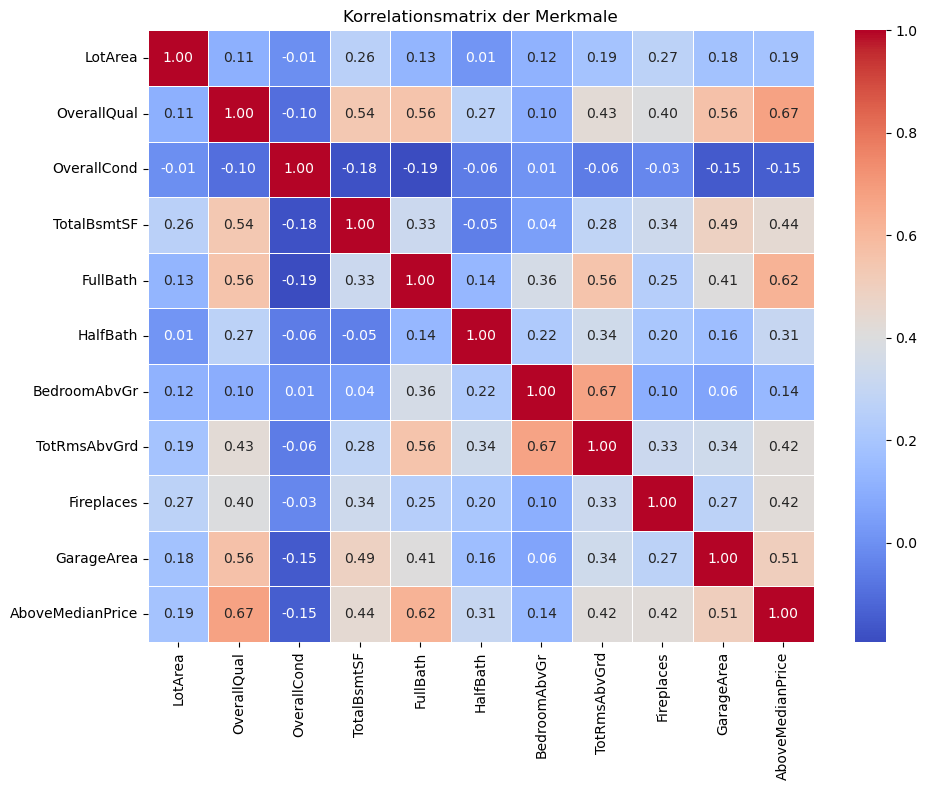

In [17]:
# Korrelationsmatrix berechnen
corr = house_df.corr()

# Heatmap mit Korrelationswerten
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,            # Korrelationswerte einbinden
    cmap="coolwarm",
    linewidths=0.5,
    annot=True,      # Korrelationswerte in die Quadrate schreiben
    fmt=".2f"        # Formatierung der Zahlen
)
plt.title("Korrelationsmatrix der Merkmale")

plt.tight_layout()
plt.show()

**Auswertung**

Die Korrelationsmatrix verdeutlicht noch einmal die prädikative Relevanz der einzelnen Variablen wie Kapitel 4.2 zeigte. Daneben zeigt die Matrix jedoch auch eindeutig Multikollinearitäten in folgenden Variablen-Clustern:

- **Cluster A**: TotalBsmtSF  <-> OverallQual (0.54) und Garage Area (0.49)
  Diese Variablen messen Größe, Wertigkeit und Ausstattung des Hauses. Sie sind inhaltlich redundant.
- **Cluster B**: FullBath     <-> OverallQual (0.55) und TotRmsAbvGrd (0.55)
  Auch besteht eine inhaltliche Redundanz: Mehr Räume, also auch mehr Badezimmer führen zu höherer Qualität.
- **Cluster C**: BedroomAbvGr <-> TotRmsAbvGrd (0.68)
  TotRmsAbvGrd enthält BedroomAbvGrd bereits. Also besteht auch hier Redundanz.

Die Zusammenhänge erklären sich auch intuitiv. OverallQual ist sozusagen ein "Meta-Merkmal", das andere Merkmale enthält und möglicherweise subjektive Aspekte (bspw. durch den Immobilien-Gutachter) einschließt. Diese Merkmal erzeugt starke Kollinearität und andere Merkmal treten dadurch in den Hintergrund. Auch die Merkmale TotRmsAbvGrd und TotalBsmtSF führen zu starker Kollinearität, da sie andere Merkmale enthalten. Durch Reduktion der Prädikatorenliste um die vorgenannten Merkmal, würde ein nicht-redundanter Merkmalsraum entstehen.

### 4.4 Gesamtauswertung EDA und Merkmalsauswahl

Die explorative Datenanalyse zeigt ein konsistentes Bild über die prädiktive Relevanz der Merkmale. Die bivariate Analyse identifiziert jene Variablen, die die beiden Preisgruppen am deutlichsten trennen. Besonders OverallQual, FullBath, GarageArea, TotalBsmtSF, Fireplaces und TotRmsAbvGrd weisen klare Lageunterschiede und hohe Korrelationen auf und bilden damit die stärksten Prädiktoren. HalfBath zeigt mittlere Trennschärfe, während LotArea, BedroomAbvGr und OverallCond aufgrund hoher Überlappungen oder nicht‑linearer Muster nur geringe prädiktive Relevanz besitzen.

Die multivariate Analyse ergänzt diese Ergebnisse um die strukturelle Perspektive: Mehrere der starken Prädiktoren sind untereinander deutlich korreliert. Besonders die Cluster aus Qualitäts‑, Größen‑ und Ausstattungsmerkmalen sowie das Raumcluster (BedroomAbvGr ↔ TotRmsAbvGrd) weisen klare Redundanzen auf. Diese Überschneidungen sind inhaltlich plausibel, da einige Variablen Teilmengen anderer Merkmale darstellen oder ähnliche Aspekte der Hausgröße und -qualität abbilden. Für lineare Modelle ist eine Reduktion kollinearer Merkmale notwendig, um stabile und interpretierbare Ergebnisse zu gewährleisten.

Da einige Klassifikationsverfahren, wie die logistische Regression empfindlich auf Multikollinearität reagieren, sollten stark korrelierte Variablen ausgeschlossen werden. RandomForest und der k-Nearest-Neighbors-Algorithmus sind in dieser Hinsicht robuster. Doch verhindert der Ausschluss solcher Variablen, dass sich die Interpretierbarkeit der Vorhersagemodell verschlechtert. Aus der explorativen Datenanalyse ergibt sich vor diesem Hintergurnd eine redundanzarme und prädiktiv sinnvolle Merkmalsauswahl. Die stärksten, nicht‑kollinearen Prädiktoren sind:

- **FullBath**
- **GarageArea**
- **Fireplaces**

Diese Kernliste ist gut interpretierbar und frei von starker Multikollinearität.
Zur Verbesserung der Modellgüte – insbesondere für nicht‑lineare Modelle – werden zwei weitere Merkmale ergänzt, die keine starke Kollinearität einführen und zusätzliche Varianz aufklären können:

- **LotArea**
- **HalfBath**

Die Aufnahme von LotArea stellt dabei einen bewussten Kompromiss dar: Die Variable ist schwach linear korreliert, aber nicht redundant und kann zusätzliche Information liefern, sofern sie skaliert wird.

Die Merkmalsauswahl basiert vollständig auf der EDA und nicht auf Modellperformance, um Data Leakage und Overfitting zu vermeiden. Damit steht ein klar begründeter, stabiler und interpretierbarer Merkmalsraum für die Modellbildung bereit.

## 5. Modellbildung und Evaluation - Aufgabe 3b)

### 5.1 Modellauswahl

Für einen wissenschaftlich fundierten Vergleich werden drei Klassifikationsmodelle gewählt, die unterschiedliche mathematischen Prinzipien repräsentieren und damit verschiedene Perspektiven auf die Struktur des Datensatzes ermöglichen. 

Die explorative Datenanalyse hat gezeigt, dass die Merkmale sowohl lineare als auch nichtlineare Zusammenhänge zur Zielvariablen aufweisen: Einige Variablen (z.B. FullBath, GarageArea) zeigen klare lineare Lageunterschiede, während andere Merkmale (z.B. Fireplaces, HalfBath) stufenweise oder diskrete Muster aufweisen, die nichtlinear wirken. Zusätzlich deuten Interaktionen zwischen Ausstattungsmerkmalen auf komplexere Zusammenhänge hin.

Vor diesem Hintergrund werden drei Modelle gewählt, die zum einen unterschiedliche Fähigkeiten im Umgang mit Strukturtypen abdecken. Und zum anderen unterscheiden sich die Modelle hinsichtlich ihrer Annahmen, ihrer Sensitivität gegenüber Skalierung und Mulitkollinearität sowie ihrer Fähigkeit, nichtlineare Zusammenhänge abzubilden. Durch diese gezielte Modellvielfalt entsteht eine robuste Grundlage für die spätere Evaluation.

**Logistische Regression - lineares Basismodell**<br>
Die logistische Regression dient als lineares Referenzmodell. Sie zeigt, in welchem Ausmaß die Zielvariable durch log-lineare Zusammenhänge erklärbar ist. Das Modell ist gut interpretierbar, effizient, reagiert jedoch sensibel auf Multikollinearität sowie unskalierte Merkmale. Aufgrund dieser Eigenschaften eignet es sich hervorragend als Baseline, an der komplexere Modelle gemessen werden können.  Gleichzeitig ermöglicht die logistische Regression eine klare Einschätzung, ob die Trennbarkeit der Klassen überwiegend log-linearer Natur ist. 

**k-Nearest_Neighbors (KNN) - distanzbasiertes Modell**<br>
Der k-Nearest-Neighbors-Algorithmus repräsentiert ein nichtparametrisches, distanzbasiertes Verfahren. Es prüft, wie gut die Klassen im Merkmalsraum durch lokale Nachbarschaftsstrukturen trennbar ist. Da das Modell ausschließlich auf Distanzen basiert, ist es besonders empfindlich gegenüber Skalierung, Ausreißer und irrelevanten Merkmalen. KNN eignet sich daher ideald, um zu untersuchen, ob die Daten eine klare geometrische Struktur aufweisen und, ob die Klassen lokal gut separierbar sind. Gleichzeitig bildet es einen Gegenpol zur logistischen Regression, da es keine linearen Annahmen trifft.

**Random Forest- baumbasiertes Ensemblemodell**<br>
Der Random Forest ist ein baumbaisertes Ensembleverfahren, das komplexe, nichtlineare Zusammenhänge sowie Interaktionen zwischen Merkmalen modellieren kann. Das Modell ist robust gegenüber Ausreißern und unempfindlich gegenüber Multikollinearität. Darüber hinaus liefert es modellbasierte Feature Importances, die eine zusätzliche Validierung der zuvor durchgeführten explorativen Datenanalyse ermöglichen. Aufgrund seiner Flexibilität eignet sich der Random Forest besonders gut für heterogene Datensätze wie diesen, in denen vermutlich sowohl lineare als auch nichtlineare Strukturen vorliegen.

Die **Kombination aus linearer Regression, distanzbasiertem KNN und nichtlinearem Random Forest** deckt ein breites Spektrum an möglicher Datenstruktur ab:

- **Lineare Zusammenhänge** werden durch die logistische Regression abgebildet.
- **Geometrische Trennbarkeit** wird durch KNN geprüft.
- **Nichlineare Muster und Interaktionen** werden durch den Random Forest erfasst.

Da der Datensatz sowohl lineare als auch nichtlineare Beziehungen enthält, ist zu erwarten, dass die Modelle unterschiedlich performen. Diese Unterschiede sind nicht zufällig, sondern ergeben sich aus den mathematischen Eigenschaften der Verfahren. Der Vergleich der drei Modellklassen ermöglicht daher eine wissenschaftlich fundierte Bewertung der Modellgüte und der zugrundeliegenden Datenstruktur.

Die **finale Prädiktorenliste** wurde so gewählt, dass sie einerseits starke bis mittelstarke 
Zusammenhänge mit der Zielvariable aufweist, andererseits aber keine Multikollinearität erzeugt. 
Variablen wie OverallQual, TotalBsmtSF und TotRmsAbvGrd wurden bewusst ausgeschlossen, da sie 
entweder Meta-Variablen darstellen oder starke Kollinearität mit anderen Merkmalen aufweisen. 
Dies verbessert insbesondere die Stabilität und Interpretierbarkeit der logistischen Regression 
und verhindert Verzerrungen in distanzbasierten Modellen wie KNN. Es wird für alle drei Modelle dieselbe Prädikatorenliste gewählt, um diw Modelle miteinander vergleichen zu können.



Die Kombination aus kollinearitätsfreier Merkmalsauswahl und heterogenen Klassifikationsverfahren 
liefert eine robuste Grundlage für eine wissenschaftlich saubere Modellierung und Evaluation.

### 5.2 Modellimplementierung
Auf Basis der zuvor begründeten Modellwahl und der kollinearitätsfreien Prädikatorenliste erfolgt im nächsten Schritt die praktische Implementierung der drei Klassifikationsmodelle. Alle Modelle werden auf demselben Trainings- und Testdatensatz ausgeführt, um eine Vergleichbarkeit sicherzustellen. Numerische Variablen werden standardisiert, sofern das Modell dies erfordert (insbesondere KNN und logistische Regression). Anschließend werden die Modelle trainiert, auf den Testdaten evaluiert und die Ergebnisse mithilfe von Confusion-Matrizen visualisiert. Zusätzlich wird die Accuracy berechnet, da sie als übergeordnete, leicht interpretierbare Kennzahl eine schnelle Einschätzung der Gesamtgüte eines Modells ermöglicht und die Ergebnisse der Confusion-Matrix sinnvoll ergänzt. Diese Vorgehensweise ermöglicht eine systematische und methodisch saubere Bewertung der Modellgüte.

#### 5.2.1 Auswahl der Prädikatoren und der Zielvariable

In [18]:
features = ["FullBath", "GarageArea", "Fireplaces", "LotArea", "HalfBath"]
target = "AboveMedianPrice"

X = house_df[features]
y = house_df[target]

#### 5.2.2 Train-Test-Split (80/20)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

#### 5.2.3 Daten skalieren

Da die ersten beiden gewählten Klassifikationsalgorithmen (Regression und KNN) skalenempflindlich sind und die vorliegenden Daten unterschiedliche Skalenniveaus aufweisen, werden die Daten skaliert.

Für Entscheidungsbäume und den Random Forest müssen die Daten  nicht skaliert werden, auch wenn die gewählte Skalierung eine lineare Transformation ist und daher nicht die Rangordnung. Daher können im Vorfeld die Trainings- und Testdaten für alle angewandten Algorithmen skaliert werden.

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 5.2.4 Klassifikator 1: Logistische Regression

<Figure size 500x400 with 0 Axes>

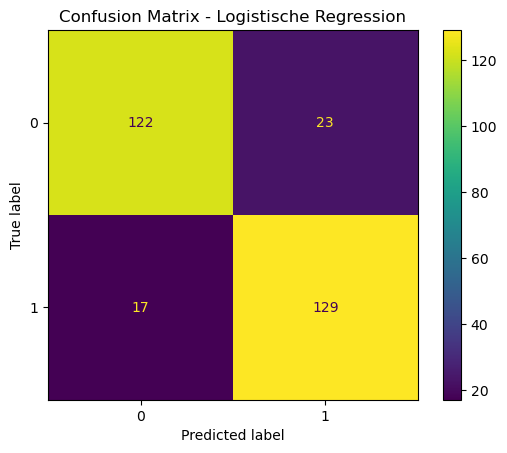

In [21]:
# Klassifikation
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

# Confusion Matrix
plt.figure(figsize=(5,4)) 
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg)
plt.title("Confusion Matrix - Logistische Regression")
plt.show()

#### 5.2.5 Klassifikator 2: k-Nearest Neighbors

<Figure size 500x400 with 0 Axes>

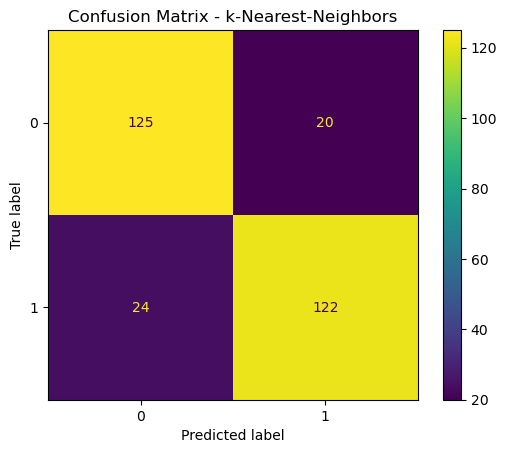

In [22]:
# Klassifikation
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Confusion-Matrix
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("Confusion Matrix - k-Nearest-Neighbors")
plt.show()

#### 5.2.6 Klassifikator 3: Random Forest

<Figure size 500x400 with 0 Axes>

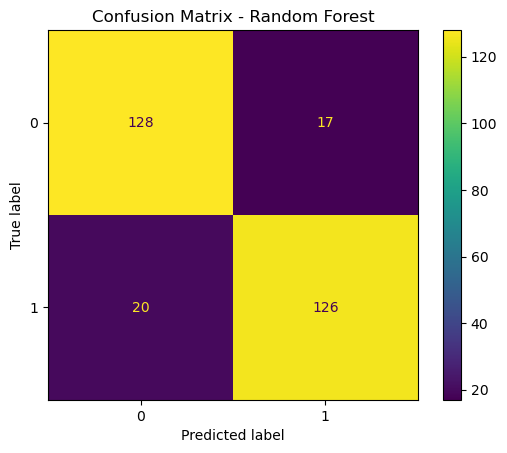

In [23]:
# Klassifikation
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)   #Random Forest benötigt keine Skalierung
y_pred_rf = rf.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

#### 5.2.7 Accuracy Scores aller Modelle

In [24]:
# Accuracy Scores sammeln
acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_knn    = accuracy_score(y_test, y_pred_knn)
acc_rf     = accuracy_score(y_test, y_pred_rf)

print("Accuracy - Logistische Regression:", acc_logreg)
print("Accuracy - k-Nearest Neighbors:", acc_knn)
print("Accuracy - Random Forest:", acc_rf)

Accuracy - Logistische Regression: 0.8625429553264605
Accuracy - k-Nearest Neighbors: 0.8487972508591065
Accuracy - Random Forest: 0.872852233676976


#### 5.2.8 Feature Importance des Random Forest

In [25]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by = "Importance", ascending = False)

feature_importance_df

,Feature,Importance
1,GarageArea,0.327198
0,FullBath,0.279425
3,LotArea,0.245017
2,Fireplaces,0.103706
4,HalfBath,0.044655


### 5.3 Evaluation der Modelle

Die drei gewählten Klassifikationsmodelle – logistische Regression, k‑Nearest Neighbors (KNN) und Random Forest – wurden auf einem konsistenten Merkmalsraum trainiert und anhand der Testdaten evaluiert. Die Bewertung erfolgt über Confusion-Matrizen, Accuracy-Werte und – im Falle des Random Forest – über die Feature Importance. Die Ergebnisse spiegeln sowohl die mathematischen Eigenschaften der Modelle als auch die in der EDA identifizierten linearen und nichtlinearen Zusammenhänge wider.

#### 5.3.1 Auswertung zur Logistischen Regression

**Confusion-Matrix:** Die logistische Regression klassifiziert beide Klassen weitgehend korrekt:

- **True Positives (129)**: Häuser über dem Medianpreis korrekt erkannt  
- **True Negatives (122)**: Häuser unter dem Medianpreis korrekt erkannt  
- **False Positives (23)**: Häuser fälschlich als „über Median“ klassifiziert  
- **False Negatives (17)**: Häuser fälschlich als „unter Median“ klassifiziert  

Die Fehlklassifikationen sind moderat und symmetrisch verteilt, was auf eine stabile lineare Trennbarkeit hinweist.

**Accuracy:** Die Accuracy beträgt **0.86** und zeigt, dass ein großer Teil der Varianz durch lineare Zusammenhänge erklärt werden kann. Dies deckt sich mit der EDA, die für mehrere Merkmale (z. B. *FullBath*, *GarageArea*) klare lineare Lageunterschiede identifiziert hat.

**Fazit:** Die logistische Regression bildet die linearen Effekte effizient ab und liefert eine starke, interpretierbare Baseline. Sie profitiert von der kollinearitätsfreien Merkmalsauswahl und der balancierten Zielvariable.

#### 5.3.2 Auswertung zum KNN

**Confusion-Matrix:** Der KNN zeigt eine solide, aber schwächere Klassifikationsleistung:

- **True Positives (122)**  
- **True Negatives (125)**  
- **False Positives (20)**  
- **False Negatives (24)**  

Auffällig ist die höhere Zahl an False Negatives, was darauf hindeutet, dass KNN Schwierigkeiten hat, die Klasse „über Medianpreis“ in einigen Randbereichen korrekt zu erkennen.

**Accuracy:** Die Accuracy beträgt **0.84** und liegt damit leicht unter der logistischen Regression.

**Fazit:** Die Performance ist methodisch erklärbar: Der KNN ist distanzbasiert und reagiert empfindlich auf  rechtsschiefe Verteilungen, Ausreißer und uungleichmäßige Dichte im Merkmalsraum . Da der Datensatz sowohl stark schiefe Variablen (z. B. *LotArea*, *TotalBsmtSF*) als auch diskrete Sprungvariablen enthält, ist die geometrische Trennbarkeit eingeschränkt. Trotz Standardisierung bleiben diese Effekte bestehen.

#### 5.3.3 Auswertung zum Random Forest

**Confusion-Matrix:** Der Random Forest erzielt die stabilste Klassifikation:

- **True Positives (126)**  
- **True Negatives (128)**  
- **False Positives (17)**  
- **False Negatives (20)**  

Die Fehlklassifikationen sind insgesamt am geringsten.

**Accuracy:** Mit einer Accuracy von **0.88** erreicht der Random Forest die beste Performance aller Modelle.
**Feature Importance:** Die Feature Importance bestätigt die Ergebnisse der EDA:

- **FullBath**, **GarageArea**, **Fireplaces** und **HalfBath** gehören zu den wichtigsten Prädiktoren.  
- Diese Merkmale zeigten bereits in den Boxplots starke Lageunterschiede zwischen den Klassen.  
- Die Wichtigkeit der Merkmale ist konsistent mit der inhaltlichen Logik des Immobilienmarktes:  
  Mehr Ausstattung → höhere Qualität → höherer Preis.

Die Feature Importance dient damit als modellbasierte Validierung der explorativen Analyse.

**Fazit:** Der Random Forest profitiert von mehreren Eigenschaften: Er modelliert Nichtlinearitäten und Interaktionen, die in der EDA sichtbar wurden. Er ist robust gegenüber Ausreißern und ist skaleninvariant. Er nutzt die diskreten Sprungvariablen (z. B. *Fireplaces*) besonders effizient.  Damit ist er für diesen Datensatz strukturell besonders geeignet.

#### 5.3.4 Übersicht zum Vergleich der Modellperformance

| Modell | Accuracy | Stärken | Schwächen |
|--------|----------|---------|-----------|
| **Random Forest** | **0.88** | Modelliert Nichtlinearitäten, robust, beste Gesamtleistung | Weniger interpretierbar |
| **Logistische Regression** | **0.86** | Interpretierbar, stabil, gute Baseline | Erfasst keine Nichtlinearitäten |
| **KNN** | **0.84** | Einfach, nichtparametrisch | Sensibel für Ausreißer und Schiefe |

##### 4.3.5 Erklärung der Performance-Unterschiede

Die Unterschiede zwischen den Modellen sind methodisch gut begründbar:

- **Random Forest** performt am besten, weil der Datensatz sowohl lineare als auch nichtlineare Muster enthält. Das Modell kann Interaktionen und Schwellenwerte abbilden und ist robust gegenüber Ausreißern.
- **Logistische Regression** performt überraschend stark, da mehrere Merkmale lineare Zusammenhänge zur Zielvariable aufweisen. Die kollinearitätsfreie Merkmalsauswahl unterstützt das Modell zusätzlich.
- **KNN** schneidet am schwächsten ab, da die Distanzstruktur durch Ausreißer, Schiefe und diskrete Variablen verzerrt wird. Diese Eigenschaften sind typisch für Immobilienmärkte und erschweren die geometrische Trennbarkeit.

### 5.4 Abschließendes Fazit

Die Evaluation zeigt, dass alle drei Modelle solide Ergebnisse liefern, jedoch unterschiedliche Aspekte der Datenstruktur nutzen. Die logistische Regression bildet die linearen Zusammenhänge effizient ab und dient als starke Baseline. KNN liefert eine alternative Perspektive auf die geometrische Trennbarkeit der Daten, ist jedoch empfindlich gegenüber Ausreißern und Schiefe. Der Random Forest erzielt die beste Performance, da er die heterogene Struktur des Datensatzes – bestehend aus linearen Effekten, diskreten Sprüngen und nichtlinearen Interaktionen – am umfassendsten modellieren kann. Die Feature Importance bestätigt zudem die prädiktiven Erkenntnisse der EDA.

Damit ist der Random Forest für diesen Datensatz das am besten geeignete Modell, während die logistische Regression eine interpretierbare und robuste Referenz darstellt.

## 6. Zusammenfassung und kritische Würdigung

Das Notebook führte systematisch durch den vollständigen datenwissenschaftlichen Workflow: von der Datenbereinigung über die explorative Analyse bis hin zur Modellbildung und Evaluation. Die EDA zeigte, dass der Datensatz sowohl lineare als auch nichtlineare Zusammenhänge enthält und dass einige Merkmale eine hohe prädiktive Relevanz besitzen. Auf dieser Grundlage wurde eine kollinearitätsfreie Prädiktorenliste erstellt, die für alle Modelle konsistent verwendet wurde, um eine Vergleichbarkeit sicherzustellen.

Die Evaluation der drei Klassifikationsmodelle – logistische Regression, KNN und Random Forest – verdeutlichte, dass jedes Modell unterschiedliche Aspekte der Datenstruktur nutzt. Die logistische Regression bildet lineare Zusammenhänge effizient ab und liefert eine robuste, gut interpretierbare Baseline. KNN bietet eine distanzbasierte Perspektive auf die geometrische Trennbarkeit der Daten, ist jedoch empfindlich gegenüber Ausreißern und rechtsschiefen Verteilungen. Der Random Forest erzielt die beste Performance, da er sowohl nichtlineare Muster als auch Interaktionen modellieren kann und gleichzeitig robust gegenüber Ausreißern und Skalierungsunterschieden ist. Die Feature Importance bestätigt zudem die prädiktive Relevanz der zuvor ausgewählten Merkmale.

Die Merkmalsauswahl spielte dabei eine zentrale Rolle: Durch den bewussten Ausschluss stark korrelierter oder redundanter Variablen wurde die Stabilität der Modelle erhöht und Verzerrungen – insbesondere bei der logistischen Regression und bei KNN – vermieden. Für weiterführende Modelloptimierungen oder praktische Anwendungen könnten jedoch je nach Modellklasse zusätzliche Merkmale wieder aufgenommen werden. Ein Random Forest oder Gradient Boosting könnte beispielsweise von Meta-Merkmalen wie *OverallQual* profitieren, während lineare Modelle weiterhin eine strikte Kollinearitätskontrolle benötigen. Die Merkmalsauswahl ist somit kein statischer Schritt, sondern sollte stets modell- und anwendungsabhängig reflektiert werden.

Insgesamt zeigt die Analyse, dass der Random Forest für diesen Datensatz die beste Balance aus Flexibilität, Robustheit und Vorhersagegüte bietet, während die logistische Regression eine interpretierbare und stabile Referenz darstellt. Die Ergebnisse unterstreichen die Bedeutung einer sorgfältigen EDA, einer begründeten Merkmalsauswahl und eines methodisch vielfältigen Modellvergleichs.

Trotz der guten Ergebnisse bestehen mehrere Ansatzpunkte für Verbesserungen:  
- Die Modelle basieren ausschließlich auf strukturellen Merkmalen; zusätzliche Informationen wie Lage, Baujahr oder Marktbedingungen könnten die Vorhersagekraft weiter erhöhen.  
- Eine Hyperparameteroptimierung wurde nicht durchgeführt und könnte insbesondere KNN und Random Forest weiter verbessern.  
- Die Merkmalsauswahl wurde bewusst konservativ gehalten, um Kollinearität zu vermeiden; für komplexere Modelle könnte eine erweiterte Feature-Engineering-Phase sinnvoll sein.  
- Schließlich wurde nur ein einfacher Train-Test-Split verwendet. Eine Kreuzvalidierung könnte die Stabilität der Ergebnisse weiter erhöhen.

Trotz dieser Einschränkungen liefert das Notebook eine fundierte, methodisch saubere und nachvollziehbare Analyse, die die Leistungsfähigkeit verschiedener Klassifikationsverfahren im Kontext von Immobilienpreisdaten überzeugend demonstriert.

## Literaturverzeichnis (zum gesamten Assignment)

### Bücher

**Behnke, Joachim (2015)**<br>
Logistische Regressionsanalyse. Eine Einführung. Springer.

**Cleve, Jürgen; Lämmel, Uwe (2016)**<br>
Data Mining. 2. Auflage, de Gruyter.

**Fischetti, Tony (2015)**<br>
Data Analysis with R. Load, wrangle, and analyze your data using the world's most powerful statistical programming language. Packt.

**Grolemund, Garret; Wickham, Hadley (2017)**<br>
R for Data Science. O'Reilly.

**Grus, Joel (2020)**<br>
Einführung in Data Science. 2. Auflage, O'Reilly.

**Handl, Andreas; Kuhlenkasper, Torben (2017)**<br>
Multivariate Analysemethoden. Theorie und Praxis mit R. 3. Auflage, Springer.

**Kirchberg, Paul (o.J.)**<br>
Methoden der statistischen Auswertung. IMG601. AKAD Bildungsgesellschaft.

**Kofler, Michael (2019)**<br>
Python. Der Grundkurs. 1. Auflage, Rheinwerk.

**Prause, Martin (o.J.)**<br>
Begleitheft zu den Fachbüchern "Einführung in Data Science: Grundprinzipien der Datenanalyse mit Python" von Grus, Joel und "Data Science mit Python" von VanderPlas, Jake. WEB305-BH. AKAD Bildungsgesellschaft.

**Prause, Martin (o.J.)**<br>
Programmiertechniken in Data Science. WEB782-FS. AKAD Bildungsgesellschaft.

**Prause, Martin (o.J.)**<br>
Programmiertechniken in Data Science. WEB781-BH. Begleitheft zum Fachbuch "Data Analysis with R" von Tony Fischetti. AKAD Bildungsgesellschaft.

**Anderson, Raymond (2007)**<br>
The Credit Scoring Toolkit: Theory and Practice for Retail Credit Risk Management and Decision Automation. Oxford University.

**Sauerbier, Thomas (o.J.)**<br>
Einfache Anwendung der Statistik. Lerneinheit 3. Regressions- und Korrelationsanalyse. AKAD Bildungsgesellschaft.

**Schmitt, Sarah (2021)**<br>
Python Kompendium. Professionell Python Programmieren lernen. BMU Media.

**Thomas, Lyn C., Edelman, David B., & Crook, Jonathan N. (2002)**<br>
Python Kompendium. Professionell Python Programmieren lernen. BMU Media.

**VanderPlas, Jake (2018)**<br>
Data Science mit Python. Das Handbuch für den EInsatz von IPython, Jupyter, NumPy, Pandas, Matplotlib, Scikit-Learn. 1. Auflage, mitp.

**Wickham, Hadley (2016)**<br>
ggplot2: Elegant Graphics for Data Analysis. Spinger.

**Woyand, Hans-Bernhard (2021)**<br>
Python für Ingenieure und Naturwissenschaftler. Einführung in die Programmierung, mathematische Anwendungen und Visualisierungen. Carl Hanser.

### Websites

**Python Software Foundation (2026)**<br>
Python Language Reference. https://docs.python.org/3/reference

**Python Software Foundation (2026)**<br>
The Python Standard Library. https://docs.python.org/3/library

**R Core Team (2026)**<br>
R: A Language and Environment for Statistical Computing. R Foundation Statistical Computing. https://www.R-project.org

**R Core Team (2026)**<br>
The R Manuals. R Foundation Statistical Computing. https://cran.r-project.org/manuals.html

**Python Software Foundation (2026)**<br>
Python Tutorial. Python Software Foundation. https://docs.python.org/3/tutorial

**Wickham, Hadley; Francois, Romain; Henry, Lionel; Müller, Kirill; Vaughan, Davis (2026)**<br>
dplyr: A Grammar of Data Manipulation. https://cran.r-project.org/web/packages/dplyr/index.html